In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("test_predictions_with_probability.csv")

In [3]:
df.columns

Index(['true_label', 'pred_label', 'prob_class0', 'prob_class1', 'CANCER_TYPE',
       'CANCER_TYPE_DETAILED'],
      dtype='object')

In [4]:
df

,true_label,pred_label,prob_class0,prob_class1,CANCER_TYPE,CANCER_TYPE_DETAILED
0,0,0,0.999996,0.000004,Prostate Cancer,Prostate Adenocarcinoma
1,0,1,0.024939,0.975061,Prostate Cancer,Prostate Adenocarcinoma
2,0,0,0.999495,0.000505,Prostate Cancer,Prostate Adenocarcinoma
3,0,0,0.999997,0.000003,Prostate Cancer,Prostate Adenocarcinoma
4,0,0,0.999997,0.000003,Prostate Cancer,Prostate Adenocarcinoma
...,...,...,...,...,...,...
12668,1,1,0.060972,0.939028,Uterine Sarcoma,Uterine Leiomyosarcoma
12669,1,0,0.952764,0.047236,Uterine Sarcoma,Uterine Sarcoma/Mesenchymal
12670,1,1,0.039781,0.960219,Uterine Sarcoma,Uterine Adenosarcoma
12671,1,0,0.794368,0.205633,Uterine Sarcoma,Uterine Leiomyosarcoma


AUROC = 0.939327


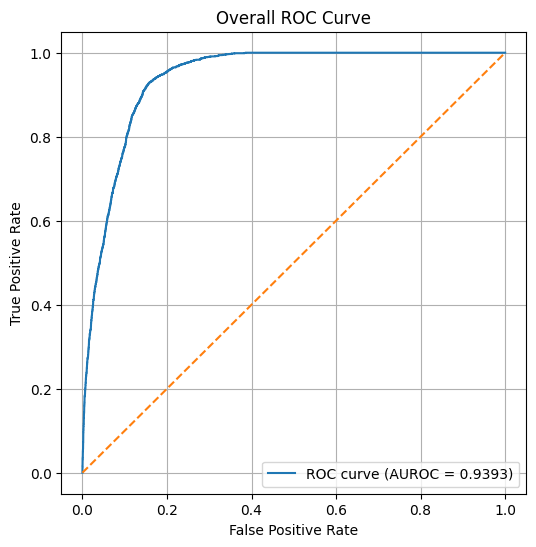

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 真实标签
y_true = df["true_label"]

# 正类(1类)的预测概率
y_score = df["prob_class1"]

# 计算 ROC 曲线
fpr, tpr, thresholds = roc_curve(y_true, y_score)

# 计算 AUROC
auroc = roc_auc_score(y_true, y_score)

print(f"AUROC = {auroc:.6f}")

# 画图
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUROC = {auroc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Overall ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

y_true = df["true_label"]
y_pred = df["pred_label"]

# 混淆矩阵: [[TN, FP],
#           [FN, TP]]
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
youden_index = sensitivity + specificity - 1
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Sensitivity = {sensitivity:.6f}")
print(f"Specificity = {specificity:.6f}")
print(f"Youden index = {youden_index:.6f}")
print(f"Accuracy = {accuracy:.6f}")
print(f"F1 score = {f1:.6f}")

Sensitivity = 0.771950
Specificity = 0.901115
Youden index = 0.673065
Accuracy = 0.874300
F1 score = 0.718302


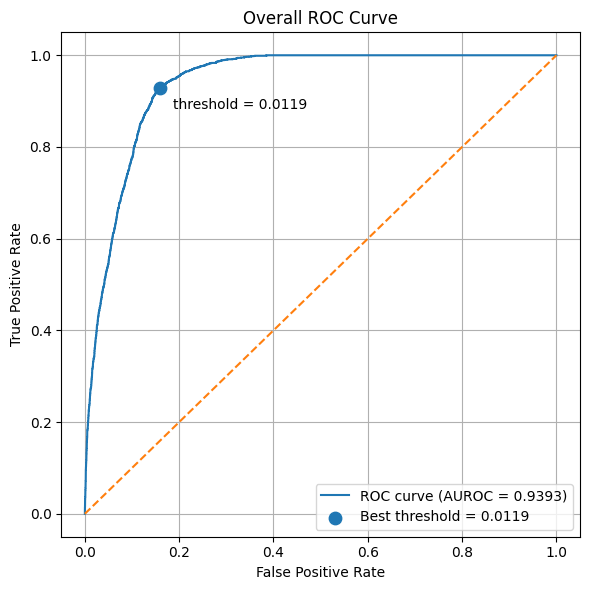

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_true = df["true_label"]
y_score = df["prob_class1"]

# ROC
fpr, tpr, thresholds = roc_curve(y_true, y_score)
auroc = roc_auc_score(y_true, y_score)

# Youden index
youden_index = tpr - fpr   # 等价于 sensitivity + specificity - 1
best_idx = np.argmax(youden_index)
best_threshold = thresholds[best_idx]
best_fpr = fpr[best_idx]
best_tpr = tpr[best_idx]

# 画图
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUROC = {auroc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

# 标记最佳 threshold 点
plt.scatter(best_fpr, best_tpr, s=80, label=f"Best threshold = {best_threshold:.4f}")
plt.annotate(
    f"threshold = {best_threshold:.4f}",
    (best_fpr, best_tpr),
    xytext=(10, -15),
    textcoords="offset points"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Overall ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

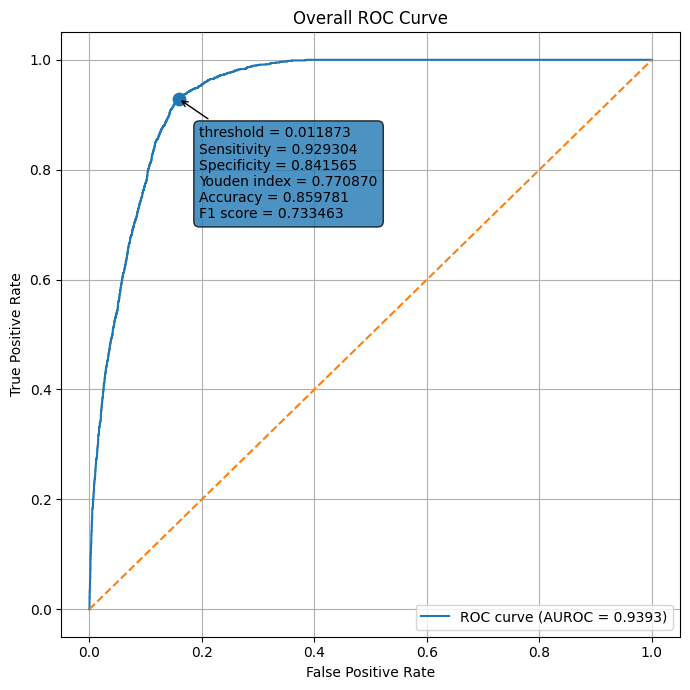

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    accuracy_score,
    f1_score
)

y_true = df["true_label"]
y_score = df["prob_class1"]

# ROC
fpr, tpr, thresholds = roc_curve(y_true, y_score)
auroc = roc_auc_score(y_true, y_score)

# 找最大 Youden index 对应的 threshold
youden_all = tpr - fpr
best_idx = np.argmax(youden_all)

best_threshold = thresholds[best_idx]
best_fpr = fpr[best_idx]
best_tpr = tpr[best_idx]

# 用最佳 threshold 重新得到预测结果
y_pred_best = (y_score >= best_threshold).astype(int)

# 计算各项指标
tn, fp, fn, tp = confusion_matrix(y_true, y_pred_best).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
youden_index = sensitivity + specificity - 1
accuracy = accuracy_score(y_true, y_pred_best)
f1 = f1_score(y_true, y_pred_best)

# 注释文字
metrics_text = (
    f"threshold = {best_threshold:.6f}\n"
    f"Sensitivity = {sensitivity:.6f}\n"
    f"Specificity = {specificity:.6f}\n"
    f"Youden index = {youden_index:.6f}\n"
    f"Accuracy = {accuracy:.6f}\n"
    f"F1 score = {f1:.6f}"
)

# 画图
plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, label=f"ROC curve (AUROC = {auroc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

# 标记最佳点
plt.scatter(best_fpr, best_tpr, s=80)

# 在点附近打印 threshold 和指标
plt.annotate(
    metrics_text,
    xy=(best_fpr, best_tpr),
    xytext=(15, -20),   # 文字相对点的位置，可自己调
    textcoords="offset points",
    ha="left",
    va="top",
    bbox=dict(boxstyle="round,pad=0.4", alpha=0.8),
    arrowprops=dict(arrowstyle="->")
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Overall ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

results = []

for cancer_type, group in df.groupby("CANCER_TYPE"):
    n = len(group)
    
    # 只保留样本数 > 200 的组
    if n <= 200:
        continue
    
    y_true = group["true_label"]
    y_score = group["prob_class1"]
    
    # 必须同时有0和1两类，否则AUC无法计算
    if y_true.nunique() < 2:
        auc = np.nan
    else:
        auc = roc_auc_score(y_true, y_score)
    
    results.append({
        "CANCER_TYPE": cancer_type,
        "N": n,
        "AUROC": auc
    })

auc_by_type_df = pd.DataFrame(results)

# 按 AUC 从高到低排序
auc_by_type_df = auc_by_type_df.sort_values(
    by="AUROC", ascending=False, na_position="last"
).reset_index(drop=True)

print(auc_by_type_df)

                   CANCER_TYPE     N     AUROC
0                     Leukemia   266  0.997017
1      Mature B-Cell Neoplasms   533  0.979825
2            Pancreatic Cancer   397  0.961312
3              Prostate Cancer   567  0.959863
4                       Glioma   658  0.949440
5           Endometrial Cancer   422  0.943327
6               Bladder Cancer   440  0.930228
7          Soft Tissue Sarcoma   417  0.926107
8         Renal Cell Carcinoma   228  0.915403
9                Breast Cancer  1682  0.914852
10   Cancer of Unknown Primary   318  0.910172
11  Non-Small Cell Lung Cancer  1596  0.896374
12      Esophagogastric Cancer   351  0.888856
13           Colorectal Cancer  1064  0.881646
14                    Melanoma   409  0.849680
15              Ovarian Cancer   469  0.844810
16                     UNKNOWN   270       NaN


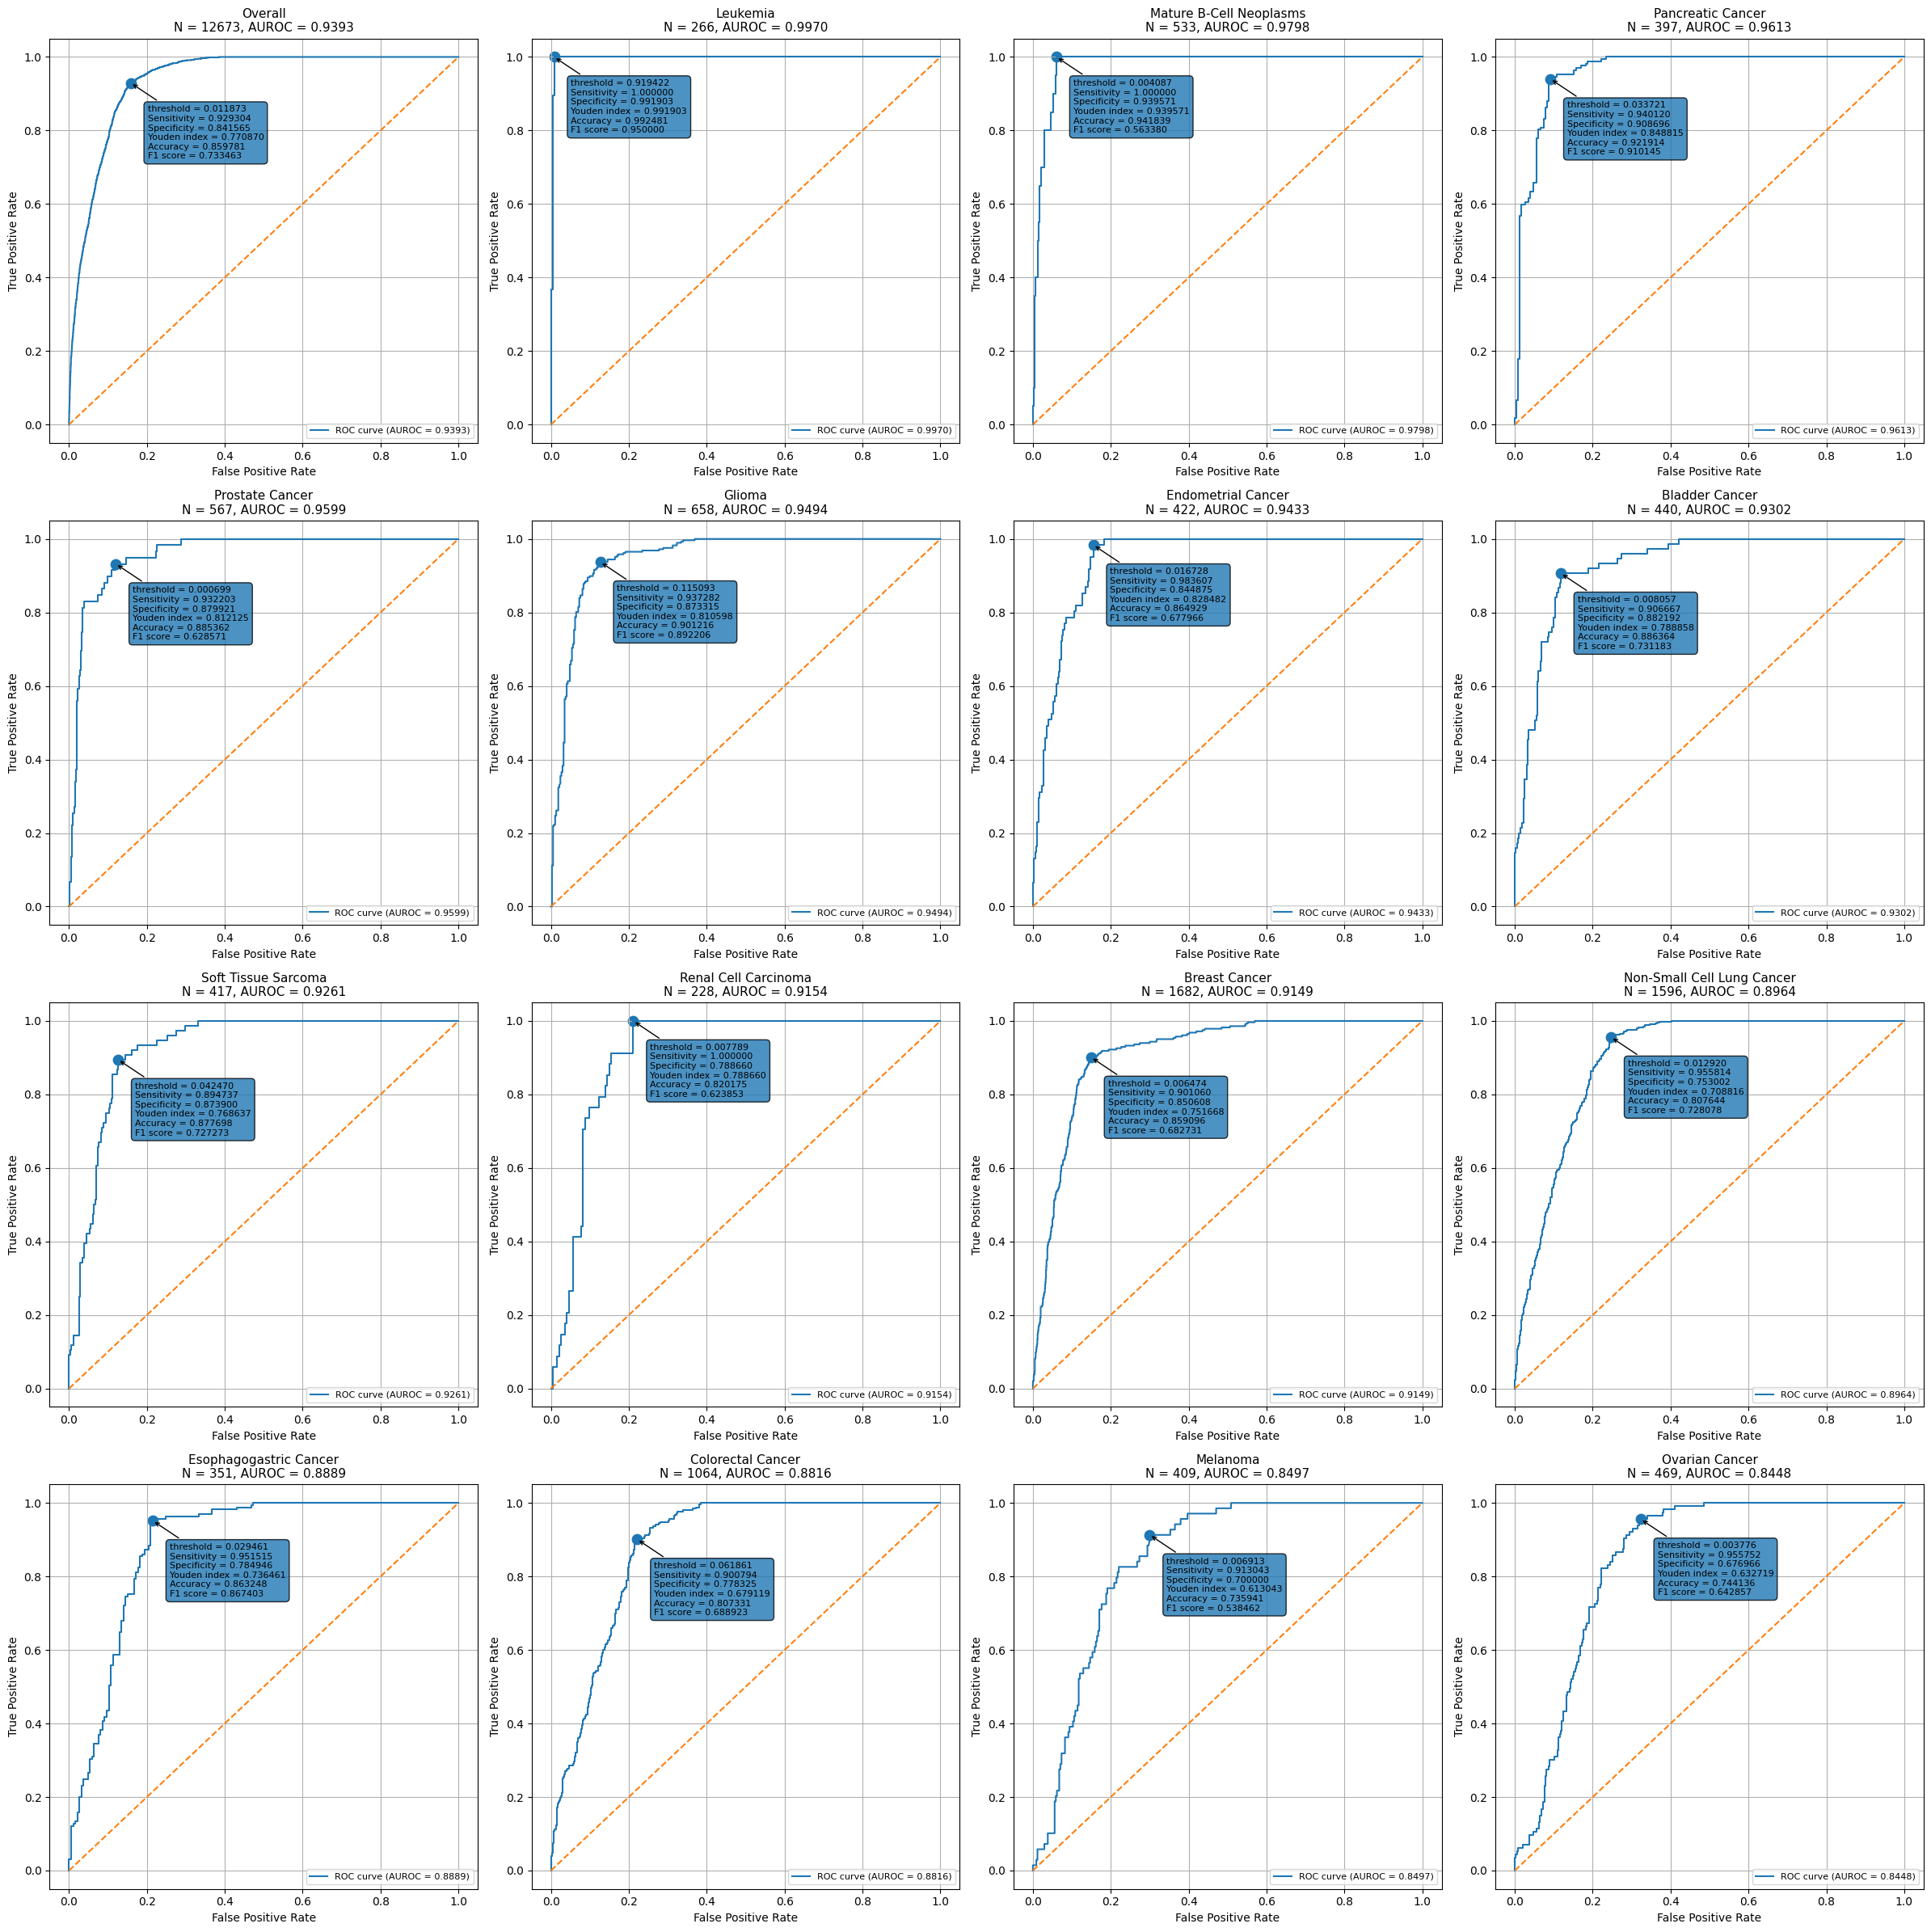

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    accuracy_score,
    f1_score
)

selected_cancer_types = [
    "Leukemia",
    "Mature B-Cell Neoplasms",
    "Pancreatic Cancer",
    "Prostate Cancer",
    "Glioma",
    "Endometrial Cancer",
    "Bladder Cancer",
    "Soft Tissue Sarcoma",
    "Renal Cell Carcinoma",
    "Breast Cancer",
    "Non-Small Cell Lung Cancer",
    "Esophagogastric Cancer",
    "Colorectal Cancer",
    "Melanoma",
    "Ovarian Cancer"
]

# 第一个放 overall，后面放 15 个癌种
plot_items = [("Overall", df)] + [
    (cancer_type, df[df["CANCER_TYPE"] == cancer_type].copy())
    for cancer_type in selected_cancer_types
]

fig, axes = plt.subplots(4, 4, figsize=(24, 24))
axes = axes.flatten()

for ax, (name, sub_df) in zip(axes, plot_items):
    n = len(sub_df)
    y_true = sub_df["true_label"]
    y_score = sub_df["prob_class1"]

    # 检查是否能计算 ROC
    if n == 0 or y_true.nunique() < 2:
        ax.text(
            0.5, 0.5,
            f"{name}\nROC not available",
            ha="center", va="center", fontsize=11
        )
        ax.set_axis_off()
        continue

    # ROC
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    auroc = roc_auc_score(y_true, y_score)

    # 最大 Youden index 对应点
    youden_all = tpr - fpr
    best_idx = np.argmax(youden_all)

    best_threshold = thresholds[best_idx]
    best_fpr = fpr[best_idx]
    best_tpr = tpr[best_idx]

    # 用最佳 threshold 得到预测结果
    y_pred_best = (y_score >= best_threshold).astype(int)

    # 计算指标
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_best).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    youden_index = sensitivity + specificity - 1
    accuracy = accuracy_score(y_true, y_pred_best)
    f1 = f1_score(y_true, y_pred_best)

    # 注释文字：和 overall 一样
    metrics_text = (
        f"threshold = {best_threshold:.6f}\n"
        f"Sensitivity = {sensitivity:.6f}\n"
        f"Specificity = {specificity:.6f}\n"
        f"Youden index = {youden_index:.6f}\n"
        f"Accuracy = {accuracy:.6f}\n"
        f"F1 score = {f1:.6f}"
    )

    # 画 ROC
    ax.plot(fpr, tpr, label=f"ROC curve (AUROC = {auroc:.4f})")
    ax.plot([0, 1], [0, 1], linestyle="--")

    # 标记最佳点
    ax.scatter(best_fpr, best_tpr, s=80)

    # 注释框
    ax.annotate(
        metrics_text,
        xy=(best_fpr, best_tpr),
        xytext=(15, -20),
        textcoords="offset points",
        ha="left",
        va="top",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.4", alpha=0.8),
        arrowprops=dict(arrowstyle="->")
    )

    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{name}\nN = {n}, AUROC = {auroc:.4f}", fontsize=11)
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True)

# 如果有多余子图，隐藏
for i in range(len(plot_items), len(axes)):
    axes[i].set_axis_off()

plt.tight_layout()
plt.show()

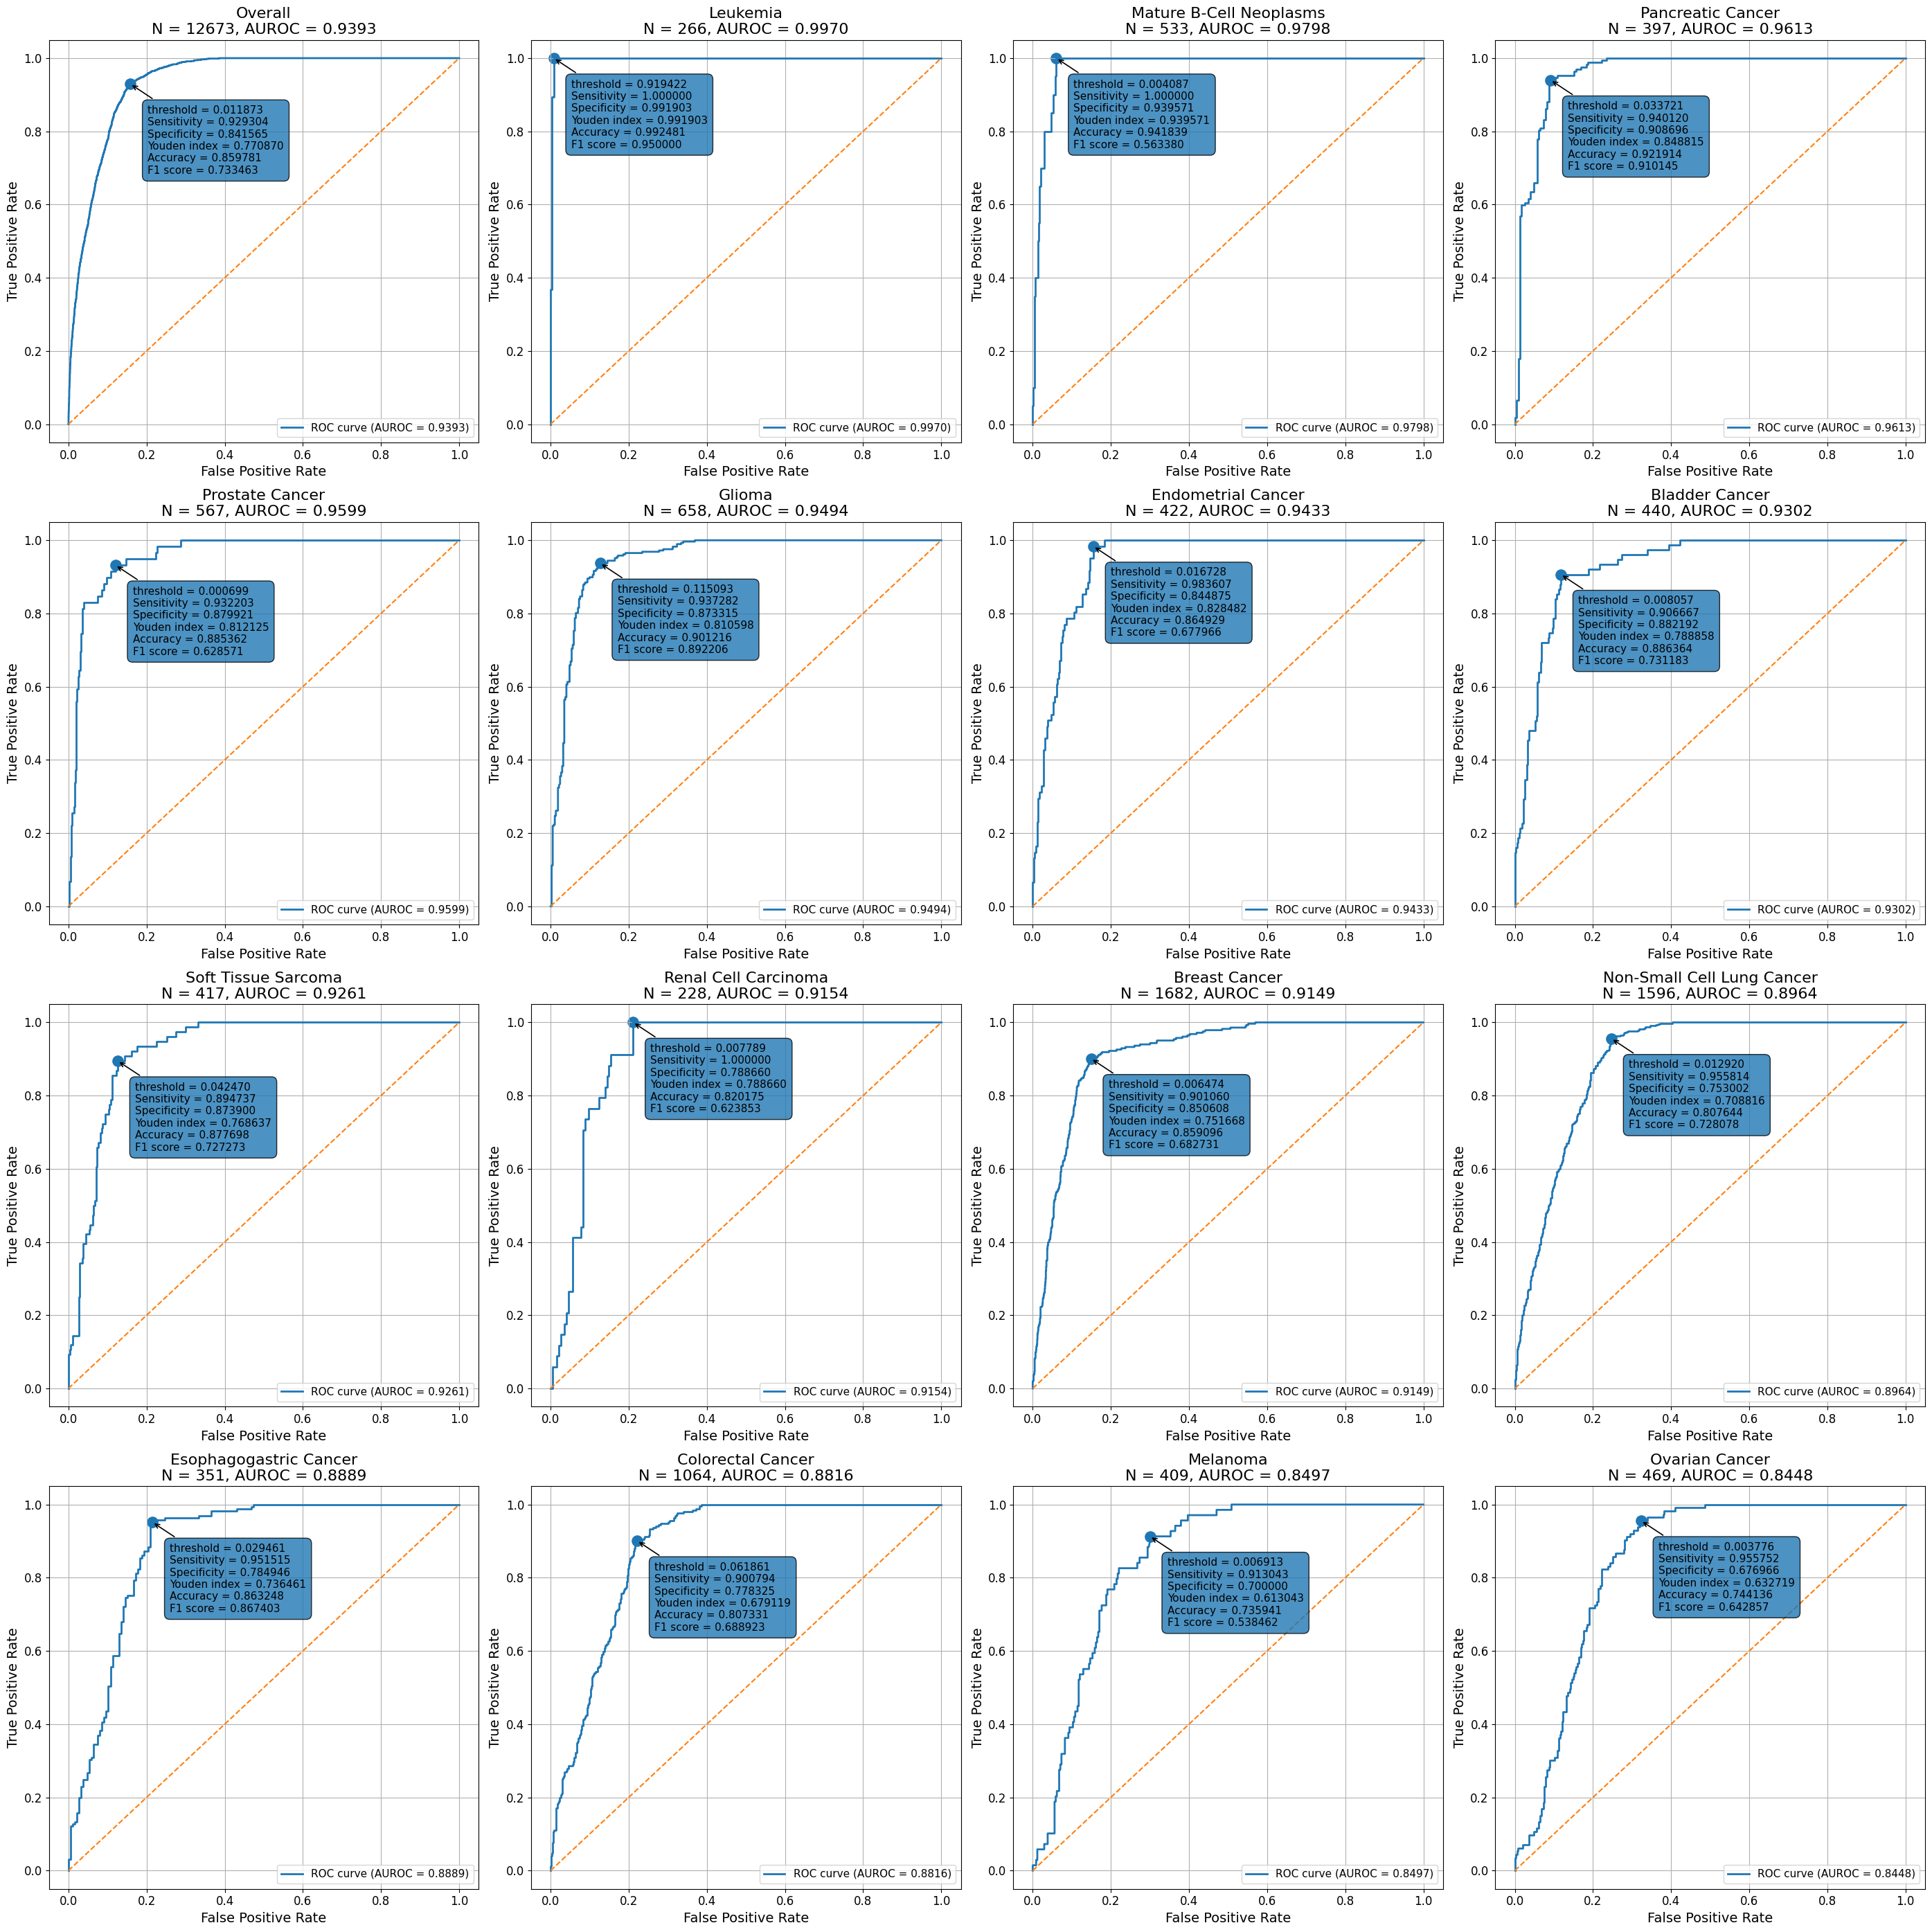

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    accuracy_score,
    f1_score
)

selected_cancer_types = [
    "Leukemia",
    "Mature B-Cell Neoplasms",
    "Pancreatic Cancer",
    "Prostate Cancer",
    "Glioma",
    "Endometrial Cancer",
    "Bladder Cancer",
    "Soft Tissue Sarcoma",
    "Renal Cell Carcinoma",
    "Breast Cancer",
    "Non-Small Cell Lung Cancer",
    "Esophagogastric Cancer",
    "Colorectal Cancer",
    "Melanoma",
    "Ovarian Cancer"
]

plot_items = [("Overall", df)] + [
    (cancer_type, df[df["CANCER_TYPE"] == cancer_type].copy())
    for cancer_type in selected_cancer_types
]

fig, axes = plt.subplots(4, 4, figsize=(28, 28))
axes = axes.flatten()

for ax, (name, sub_df) in zip(axes, plot_items):
    n = len(sub_df)
    y_true = sub_df["true_label"]
    y_score = sub_df["prob_class1"]

    if n == 0 or y_true.nunique() < 2:
        ax.text(
            0.5, 0.5,
            f"{name}\nROC not available",
            ha="center", va="center", fontsize=16
        )
        ax.set_axis_off()
        continue

    # ROC
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    auroc = roc_auc_score(y_true, y_score)

    # best threshold by Youden index
    youden_all = tpr - fpr
    best_idx = np.argmax(youden_all)

    best_threshold = thresholds[best_idx]
    best_fpr = fpr[best_idx]
    best_tpr = tpr[best_idx]

    y_pred_best = (y_score >= best_threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_best).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    youden_index = sensitivity + specificity - 1
    accuracy = accuracy_score(y_true, y_pred_best)
    f1 = f1_score(y_true, y_pred_best)

    metrics_text = (
        f"threshold = {best_threshold:.6f}\n"
        f"Sensitivity = {sensitivity:.6f}\n"
        f"Specificity = {specificity:.6f}\n"
        f"Youden index = {youden_index:.6f}\n"
        f"Accuracy = {accuracy:.6f}\n"
        f"F1 score = {f1:.6f}"
    )

    ax.plot(fpr, tpr, label=f"ROC curve (AUROC = {auroc:.4f})", linewidth=2)
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5)

    ax.scatter(best_fpr, best_tpr, s=120)

    ax.annotate(
        metrics_text,
        xy=(best_fpr, best_tpr),
        xytext=(18, -22),
        textcoords="offset points",
        ha="left",
        va="top",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.5", alpha=0.8),
        arrowprops=dict(arrowstyle="->", lw=1.2)
    )

    ax.set_xlabel("False Positive Rate", fontsize=14)
    ax.set_ylabel("True Positive Rate", fontsize=14)
    ax.set_title(f"{name}\nN = {n}, AUROC = {auroc:.4f}", fontsize=16)
    ax.legend(loc="lower right", fontsize=11)
    ax.grid(True)
    ax.tick_params(axis='both', labelsize=12)

for i in range(len(plot_items), len(axes)):
    axes[i].set_axis_off()

plt.tight_layout()
plt.savefig("roc_4x4_overall_plus_15_types.png", dpi=300, bbox_inches="tight")
plt.savefig("roc_4x4_overall_plus_15_types.pdf", bbox_inches="tight")
plt.show()